# Subtask 1 - Encoder-Only Transformers for Relational Reasoning

## By Abhisek Mohapatra

In [1]:
# importing libraries
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
dataset = pd.read_csv("./ranking_dataset.csv")

dataset.head()

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6


In [4]:
len(dataset)

10000

In [5]:
from torch.utils.data import Dataset,DataLoader,random_split

class NumArrayDataset(Dataset):
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = self.data[:,10:]
        tmp = np.zeros((len(self.data),10,10))
        for i in range(len(self.data)):
            for j in range(10):
                tmp[i,j,self.y[i,j]] = 1
        self.y = tmp.reshape(-1,100)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] -= self.x[i].mean()
        self.x[i] /= self.x[i].std()
        return (self.x[i],self.y[i])
        
        
    

In [6]:
dataset_trh = NumArrayDataset(dataset)
print(dataset_trh[0])

(tensor([ 0.1557, -1.1821,  1.0964, -0.2048, -1.2975, -0.4273,  0.3754,  1.2316,
         1.3049, -1.0525]), array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]))


# Making a MLP for predicting the order

In [7]:
valid_ratio = .1
test_ratio = .1

test_size = int(test_ratio*len(dataset_trh))
valid_size = int(valid_ratio*len(dataset_trh))
training_size = len(dataset_trh) - test_size - valid_size


(train_dataset, test_dataset, valid_dataset) = random_split(dataset_trh, [training_size,test_size,valid_size])

In [8]:
train_data = DataLoader(train_dataset, batch_size=128)
valid_data = DataLoader(valid_dataset, batch_size=128)

In [9]:
class MLPPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(10,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,256),
            torch.nn.ReLU(),
            torch.nn.Linear(256,100)
        )

    def forward(self,x):
        return self.model(x)
    

In [10]:
model = MLPPredictor()

loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = 3e-3)

max_epochs = 100
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        n = 0
        for (x,y) in valid_data:
            pred = model(x)
            pred = pred.reshape(-1,10,10)
            pred = np.argmax(pred,axis=2).reshape(-1)
            y = y.reshape(-1,10,10)
            y = np.argmax(y,axis=2).reshape(-1)
            n += len(y)
            total += (y == pred).sum()
        
    if (i%10 == 0):print(total/n)

tensor(0.3737)
tensor(0.5866)
tensor(0.6185)
tensor(0.6360)
tensor(0.6512)
tensor(0.6542)
tensor(0.6656)
tensor(0.6733)
tensor(0.6785)
tensor(0.6874)


In [11]:
test_data = DataLoader(test_dataset, batch_size=128)

model.eval()
total = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        pred = model(x)
        pred = pred.reshape(-1,10,10)
        pred = np.argmax(pred,axis=2).reshape(-1)
        y = y.reshape(-1,10,10)
        y = np.argmax(y,axis=2).reshape(-1)
        n += len(y)
        total += (y == pred).sum()

print(total/n)

tensor(0.6894)


In [12]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        pred = model(x)
        pred = pred.reshape(10,10)
        pred = np.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(10,10)
        y = np.argmax(y,axis=1).reshape(-1)
        print(f"{i+1} testcase")
        print("pred : ",x.numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
pred :  [ 0.21486473  0.9165527  -0.45631513 -1.0534036   1.4613416  -1.0228955
  1.1344683  -0.5565563   0.6332625  -1.2713192 ]
pred :  [5 7 3 1 9 2 8 3 7 0]
true :  [5 7 4 1 9 2 8 3 6 0]
10 testcase
pred :  [ 1.2156945   1.0391515  -0.3633843  -0.53502333 -0.20645721 -0.3094406
  1.8581148  -0.8439735  -0.90772516 -0.94695693]
pred :  [8 7 5 3 6 5 9 1 1 0]
true :  [8 7 4 3 6 5 9 2 1 0]
15 testcase
pred :  [-0.92551565  1.8217721   0.40808922  1.1873088  -0.6976016  -1.1534296
  0.10625718 -1.1441898   0.07237808  0.3249314 ]
pred :  [2 9 6 8 3 1 5 0 5 6]
true :  [2 9 7 8 3 0 5 1 4 6]
20 testcase
pred :  [-1.0901136  -1.0504442   0.20839629  1.3244271   1.3297164  -0.46862718
  0.03914041 -1.2249894   1.1683944  -0.23590037]
pred :  [1 1 5 8 9 3 5 0 8 4]
true :  [1 2 6 8 9 3 5 0 7 4]
25 testcase
pred :  [ 0.44210875 -0.78186774  0.87208325  1.0013394   1.1121304  -1.4466136
 -0.97179514 -1.2434968   0.29174957  0.72436196]
pred :  [5 2 8 8 9 0 2 0 5 6]
true :  [5 3 7 8 9 0

# Testing RNN and LSTM
## To see if memory helps

In [13]:
from torch.utils.data import Dataset,DataLoader,random_split

class NumArrayDataset(Dataset):
    def __init__(self,data):
        self.data = np.array(data,dtype = "float32")
        self.x = torch.Tensor(self.data[:,:10])
        
        self.y = np.array(self.data[:,10:],dtype="int")
        tmp = np.zeros((len(self.data),10,10))
        for i in range(len(self.data)):
            for j in range(10):
                tmp[i,j,self.y[i,j]] = 1
        self.y = torch.Tensor(tmp.reshape(-1,100))
        

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] -= self.x[i].mean()
        self.x[i] /= self.x[i].std()
        return (self.x[i],self.y[i])
        
    

In [14]:
dataset_trh = NumArrayDataset(dataset)
dataset_trh[0]

(tensor([ 0.1557, -1.1821,  1.0964, -0.2048, -1.2975, -0.4273,  0.3754,  1.2316,
          1.3049, -1.0525]),
 tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]))

In [15]:
valid_ratio = .1
test_ratio = .1

test_size = int(test_ratio*len(dataset_trh))
valid_size = int(valid_ratio*len(dataset_trh))
training_size = len(dataset_trh) - test_size - valid_size

gen1 = torch.Generator().manual_seed(42)
(train_dataset, test_dataset, valid_dataset) = random_split(dataset_trh, [training_size,test_size,valid_size],generator=gen1)

In [16]:
train_data = DataLoader(train_dataset, batch_size=128)
valid_data = DataLoader(valid_dataset, batch_size=512)

In [17]:
class SimpleRNNPredictor(torch.nn.Module):
    def __init__(self,history):
        super().__init__()
        self.history = history
        self.W_y = nn.Sequential(
            torch.nn.Linear(self.history+1,64),
            torch.nn.ReLU(),
            torch.nn.Linear(64,10),
        )
        self.W_h = nn.Sequential(
            torch.nn.Linear(self.history+1,64),
            torch.nn.ReLU(),
            torch.nn.Linear(64,self.history),
        )

    def forward(self,x):
        h = torch.randn(len(x),self.history).to(device)
        outputs = []
        for i  in range(10):
            combined_inputs = torch.concat((h,x[:,i:i+1]),dim = 1)
            o = self.W_y(combined_inputs)
            outputs.append(o)
            h =self.store(combined_inputs)
        y = torch.concat(outputs,dim=1)
        return y

    def store(self,combined_inputs):
        return torch.tanh(self.W_h(combined_inputs))
    

In [18]:
model = SimpleRNNPredictor(64)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = 9e-4)

max_epochs = 100
model.train()
accuracies = []
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = y == pred
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
        accuracies.append(total.cpu()/valid_size/10)
    if (i%10 == 0):
        print(accuracies[-1])
        print(s/training_size)

tensor(0.2037)
0.354227285861969
tensor(0.5268)
0.28219158029556274
tensor(0.6416)
0.2624118275642395
tensor(0.6849)
0.254492045879364
tensor(0.7010)
0.2504989438056946
tensor(0.7095)
0.2484660379886627
tensor(0.7164)
0.24634010338783263
tensor(0.7162)
0.2447417869567871
tensor(0.7220)
0.24349946236610412
tensor(0.7295)
0.24273488998413087


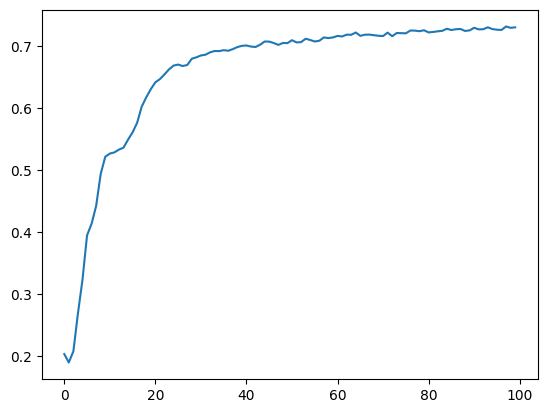

In [19]:
plt.plot(accuracies)

In [20]:
test_data = DataLoader(test_dataset, batch_size=128)

model.eval()
total2 = 0
n = 0
with torch.no_grad():
    total = 0
    for (x,y) in test_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            #pred = torch.sigmoid(pred)*10
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = (y == pred)
            total2+=z.sum()
            z = z.reshape(-1,10)
            total += torch.where(torch.sum(z,dim = 1) == 10, 1,0).sum()

print(total/test_size,total2/test_size/10)

tensor(0.0810, device='cuda:0') tensor(0.7333, device='cuda:0')


In [21]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device)
        y = y.to(device)
        pred = model(x.reshape(1,-1))
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        #pred = torch.sigmoid(pred)*10
        print(f"{i+1} testcase")
        print("x : ",x)
        print("pred : ",pred)
        print("true : ",y)

5 testcase
x :  tensor([-0.7413,  1.6795,  0.6962, -0.6798, -1.0554,  1.3927, -1.1715,  0.2045,
        -0.4476,  0.1226], device='cuda:0')
pred :  tensor([4, 4, 0, 3, 8, 9, 7, 2, 5, 1], device='cuda:0')
true :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1], device='cuda:0')
10 testcase
x :  tensor([-0.1977, -1.0546,  0.0791,  0.5932, -0.1780, -0.2768,  1.7532, -0.5998,
         1.3446, -1.4632], device='cuda:0')
pred :  tensor([9, 1, 7, 5, 4, 2, 3, 3, 8, 6], device='cuda:0')
true :  tensor([9, 1, 7, 5, 0, 4, 2, 3, 8, 6], device='cuda:0')
15 testcase
x :  tensor([-0.7236, -0.1601, -0.9237, -0.4173,  2.2777, -0.6174,  0.3912, -0.0253,
        -0.8175,  1.0160], device='cuda:0')
pred :  tensor([8, 2, 0, 5, 3, 1, 7, 6, 9, 4], device='cuda:0')
true :  tensor([2, 8, 0, 5, 3, 1, 7, 6, 9, 4], device='cuda:0')
20 testcase
x :  tensor([ 0.9473, -0.1162,  1.7517, -1.1934, -1.1320,  0.6712,  0.4155, -0.1674,
        -1.2854,  0.1087], device='cuda:0')
pred :  tensor([8, 4, 4, 1, 7, 9, 6, 5, 0, 2], device

In [22]:
class TrhRNNPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        # Built-in RNN layer
        self.rnn = nn.RNN(input_size=1, 
                          hidden_size=64, 
                          num_layers=1,
                          batch_first=True)
        
        # Output layer
        self.fc = nn.Linear(64, 100)
    
    def forward(self, x):
        """
        x: input of shape (batch_size, seq_length, input_size)
        """
        # RNN returns (output, h_n)
        rnn_out, h_n = self.rnn(x.reshape(-1,10,1))
        
        # Take the output from the last time step
        #print(rnn_out.shape)
        last_output = rnn_out[:,-1,:]  # Shape: (batch_size, hidden_size)
        
        # Pass through output layer
        output = self.fc(last_output)
        
        return output

In [23]:
model = TrhRNNPredictor()
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = 6e-3)

max_epochs = 100
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = y == pred
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
        
    if (i%10 == 0):
        print(total/valid_size/10)

tensor(0.2362, device='cuda:0')
tensor(0.6367, device='cuda:0')
tensor(0.7067, device='cuda:0')
tensor(0.7393, device='cuda:0')
tensor(0.7532, device='cuda:0')
tensor(0.7662, device='cuda:0')
tensor(0.7769, device='cuda:0')
tensor(0.7791, device='cuda:0')
tensor(0.7855, device='cuda:0')
tensor(0.7823, device='cuda:0')


In [24]:
test_data = DataLoader(test_dataset, batch_size=128)

model.eval()
total = 0
total2 = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        z = (y == pred)
        total2+=z.sum()
        z = z.reshape(-1,10)
        total += torch.where(torch.sum(z,dim = 1) == 10, 1,0).sum()

print(total2/test_size/10,total/test_size)

tensor(0.7835, device='cuda:0') tensor(0.1310, device='cuda:0')


In [25]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        y = y.to(device)
        x = x.to(device)
        pred = model(x.reshape(1,-1))
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x)
        print("pred : ",pred)
        print("true : ",y)

5 testcase
x :  tensor([-0.7413,  1.6795,  0.6962, -0.6798, -1.0554,  1.3927, -1.1715,  0.2045,
        -0.4476,  0.1226], device='cuda:0')
pred :  tensor([6, 4, 0, 0, 8, 9, 7, 2, 5, 1], device='cuda:0')
true :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1], device='cuda:0')
10 testcase
x :  tensor([-0.1977, -1.0546,  0.0791,  0.5932, -0.1780, -0.2768,  1.7532, -0.5998,
         1.3446, -1.4632], device='cuda:0')
pred :  tensor([9, 9, 7, 7, 4, 0, 2, 3, 8, 6], device='cuda:0')
true :  tensor([9, 1, 7, 5, 0, 4, 2, 3, 8, 6], device='cuda:0')
15 testcase
x :  tensor([-0.7236, -0.1601, -0.9237, -0.4173,  2.2777, -0.6174,  0.3912, -0.0253,
        -0.8175,  1.0160], device='cuda:0')
pred :  tensor([2, 8, 8, 5, 3, 7, 1, 6, 9, 4], device='cuda:0')
true :  tensor([2, 8, 0, 5, 3, 1, 7, 6, 9, 4], device='cuda:0')
20 testcase
x :  tensor([ 0.9473, -0.1162,  1.7517, -1.1934, -1.1320,  0.6712,  0.4155, -0.1674,
        -1.2854,  0.1087], device='cuda:0')
pred :  tensor([3, 4, 4, 7, 7, 9, 6, 5, 0, 2], device

In [26]:
test_data = DataLoader(test_dataset, batch_size=4096)
train_data = DataLoader(train_dataset, batch_size=64)
valid_data = DataLoader(valid_dataset, batch_size=4096)

In [27]:
class LSTMPredictor(torch.nn.Module):
    def __init__(self,history,cell_size):
        super().__init__()
        self.history = history
        self.cell_size = cell_size
        self.combined_size = self.history+1
        self.W_f = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Sigmoid(),
        )
        self.W_i1 = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Sigmoid(),
        )
        self.W_i2 = nn.Sequential(
            torch.nn.Linear(self.combined_size,self.cell_size),
            torch.nn.Tanh(),
        )
        self.W_hc = nn.Sequential(
            nn.Linear(self.cell_size,self.history),
            nn.Tanh()
        )
        self.W_hh = nn.Sequential(
            nn.Linear(self.combined_size,self.history),
            nn.Sigmoid()
        )
        self.W_oh = nn.Sequential(
            nn.Linear(self.history*10+self.cell_size+10,100)
        )

    def forward(self,x):
        h = torch.zeros(len(x),self.history).to(device)
        c = torch.zeros(len(x),self.cell_size).to(device)
        outputs = []
        for i  in range(10):
            combined_inputs = torch.concat((h,x[:,i:i+1]),dim = 1)

            # forget part
            c= c * self.W_f(combined_inputs)
            # storing info
            c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
            # getting output
            h = self.W_hh(combined_inputs) * self.W_hc(c)
            outputs.append(h)
        h = torch.concat(outputs,dim = 1)
        y = self.W_oh(torch.concat((h,c,x),dim = 1))
        return y

In [28]:
model = LSTMPredictor(64,128)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = 1e-3,weight_decay=0.01)

max_epochs = 100
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        opt.zero_grad()
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = y == pred
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
        
    if (i%10 == 0):
        print(total/valid_size/10)

tensor(0.2648, device='cuda:0')
tensor(0.7495, device='cuda:0')
tensor(0.7677, device='cuda:0')
tensor(0.7882, device='cuda:0')
tensor(0.7796, device='cuda:0')
tensor(0.8006, device='cuda:0')
tensor(0.8006, device='cuda:0')
tensor(0.7967, device='cuda:0')
tensor(0.7867, device='cuda:0')
tensor(0.7893, device='cuda:0')


In [29]:
model.eval()
total = 0
total2 = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        z = (y == pred)
        total2+=z.sum()
        z = z.reshape(-1,10)
        total += torch.where(torch.sum(z,dim = 1) == 10, 1,0).sum()

print(total2/test_size/10,total/test_size)

tensor(0.7911, device='cuda:0') tensor(0.1700, device='cuda:0')


In [30]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device)
        pred = model(x.reshape(1,-1))
        pred = pred.reshape(-1,10,10).cpu()
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = np.argmax(y,axis=1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x)
        print("pred : ",pred.numpy())
        print("true : ",y)

5 testcase
x :  tensor([-0.7413,  1.6795,  0.6962, -0.6798, -1.0554,  1.3927, -1.1715,  0.2045,
        -0.4476,  0.1226], device='cuda:0')
pred :  [6 4 0 3 8 9 7 2 5 1]
true :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1])
10 testcase
x :  tensor([-0.1977, -1.0546,  0.0791,  0.5932, -0.1780, -0.2768,  1.7532, -0.5998,
         1.3446, -1.4632], device='cuda:0')
pred :  [9 1 7 5 5 2 3 3 8 6]
true :  tensor([9, 1, 7, 5, 0, 4, 2, 3, 8, 6])
15 testcase
x :  tensor([-0.7236, -0.1601, -0.9237, -0.4173,  2.2777, -0.6174,  0.3912, -0.0253,
        -0.8175,  1.0160], device='cuda:0')
pred :  [2 8 5 5 3 1 7 6 9 4]
true :  tensor([2, 8, 0, 5, 3, 1, 7, 6, 9, 4])
20 testcase
x :  tensor([ 0.9473, -0.1162,  1.7517, -1.1934, -1.1320,  0.6712,  0.4155, -0.1674,
        -1.2854,  0.1087], device='cuda:0')
pred :  [8 4 4 1 7 9 6 5 0 2]
true :  tensor([8, 3, 4, 7, 1, 9, 6, 5, 0, 2])
25 testcase
x :  tensor([-0.6228,  0.5959, -0.8100,  0.5236, -1.5162, -1.4013,  0.5729,  1.3678,
         0.5170,  0.7732], devic

# Implementing Encoder Transformer

In [31]:
class Attention(nn.Module):
    def __init__(self,size,size2):
        super().__init__()
        self.W_Q = nn.Parameter(torch.randn((size,size2)))
        self.W_K = nn.Parameter(torch.randn((size,size2)))
        self.W_V = nn.Parameter(torch.randn((size,size2)))
        self.sf = nn.Softmax(dim=-1)
        self.size2 = size2

    def forward(self,x):
        return self.sf(1/np.sqrt(self.size2)*((x@self.W_Q)@(x@self.W_V).mT))@x@self.W_V

class AddAndNormalise(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x,y):
        h = torch.concat([x,y],dim = -1)
        return (h - h.mean())/h.std()

class EncoderOnlyTransformerPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.att = Attention(2,128)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((128+2,64)))
        self.b_1 = nn.Parameter(torch.randn(64))
        self.W_2 = nn.Parameter(torch.randn((64,10)))
        self.b_2 = nn.Parameter(torch.randn(10))
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        #print(x3.shape)
        x4 = self.norm(x2,x3)
        
        return self.ff(x4).reshape(-1,100)

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = 2**(-i)
        return torch.concat([x,P], dim = -1)

In [32]:
train_data = DataLoader(train_dataset,64)

model = EncoderOnlyTransformerPredictor()
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr = 2e-3)

max_epochs = 100
model.train()
accuracies = []
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = y == pred
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
    accuracies.append((total.cpu()/valid_size/10))
    if (i%10 == 0):
        print(accuracies[-1])

tensor(0.2951)
tensor(0.5997)
tensor(0.6438)
tensor(0.6585)
tensor(0.6664)
tensor(0.6732)
tensor(0.6682)
tensor(0.6682)
tensor(0.6771)
tensor(0.6790)


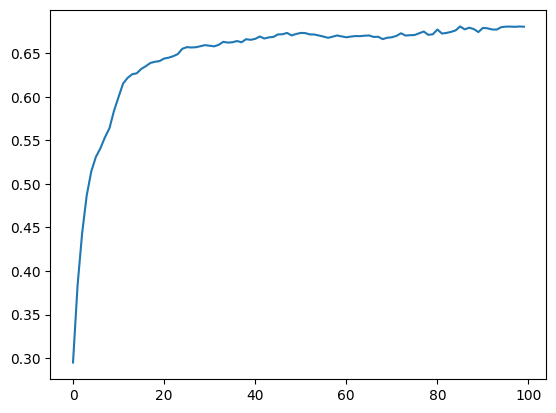

In [33]:
plt.plot(accuracies)

In [34]:
test_data = DataLoader(test_dataset, batch_size=128)

model.eval()
total = 0
total2 = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        z = (y == pred)
        total2+=z.sum()
        z = z.reshape(-1,10)
        total += torch.where(torch.sum(z,dim = 1) == 10, 1,0).sum()

print(total2/test_size/10,total/test_size)

tensor(0.6814, device='cuda:0') tensor(0.0360, device='cuda:0')


In [35]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device)
        pred = model(x.reshape(1,-1))
        pred = pred.reshape(-1,10,10).cpu()
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = np.argmax(y,axis=1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x)
        print("pred : ",pred)
        print("true : ",y)

5 testcase
x :  tensor([-0.7413,  1.6795,  0.6962, -0.6798, -1.0554,  1.3927, -1.1715,  0.2045,
        -0.4476,  0.1226], device='cuda:0')
pred :  tensor([6, 4, 3, 8, 8, 7, 2, 2, 5, 1])
true :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1])
10 testcase
x :  tensor([-0.1977, -1.0546,  0.0791,  0.5932, -0.1780, -0.2768,  1.7532, -0.5998,
         1.3446, -1.4632], device='cuda:0')
pred :  tensor([9, 1, 7, 7, 5, 2, 3, 3, 8, 6])
true :  tensor([9, 1, 7, 5, 0, 4, 2, 3, 8, 6])
15 testcase
x :  tensor([-0.7236, -0.1601, -0.9237, -0.4173,  2.2777, -0.6174,  0.3912, -0.0253,
        -0.8175,  1.0160], device='cuda:0')
pred :  tensor([2, 2, 0, 5, 1, 7, 6, 9, 9, 4])
true :  tensor([2, 8, 0, 5, 3, 1, 7, 6, 9, 4])
20 testcase
x :  tensor([ 0.9473, -0.1162,  1.7517, -1.1934, -1.1320,  0.6712,  0.4155, -0.1674,
        -1.2854,  0.1087], device='cuda:0')
pred :  tensor([8, 4, 4, 7, 7, 9, 5, 0, 0, 2])
true :  tensor([8, 3, 4, 7, 1, 9, 6, 5, 0, 2])
25 testcase
x :  tensor([-0.6228,  0.5959, -0.8100,  0.5236, 

In [36]:
class MultiHeadAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers):
        super().__init__()
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads)))
        
        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x):
        batchsize, input_len = x.shape[0],x.shape[1]
        Q = x@self.W_Q
        K = x@self.W_K
        V = x@self.W_V

        """
        previous attempt
        Qs = torch.chunk(Q,self.nheads,dim = -1)
        Ks = torch.chunk(K,self.nheads,dim = -1)
        Vs = torch.chunk(V,self.nheads,dim = -1)
        c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        return c@self.W_O
        """
        
        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)

        out = self.scaledDotProduct(Qs,Ks,Vs).transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O
        

    def scaledDotProduct(self,Q,K,V):
        return self.sf(1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(device))*(Q@(K.mT)))@V
        

In [37]:
class EncoderOnlyTransformerPredictor2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention(4,2,16)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((4*16+2,64)))
        self.b_1 = nn.Parameter(torch.randn(64))
        self.W_2 = nn.Parameter(torch.randn((64,10)))
        self.b_2 = nn.Parameter(torch.randn(10))
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        #print(x3.shape)
        x4 = self.norm(x2,x3)
        
        return self.ff(x4).reshape(-1,100)

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = 2**(-i)
        return torch.concat([x,P], dim = -1)


In [38]:
train_data = DataLoader(train_dataset,64)

model = EncoderOnlyTransformerPredictor2()
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.AdamW(model.parameters(),lr =1e-3)

max_epochs = 200
model.train()
accuracies = []
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = torch.sigmoid(pred)
            pred = pred.reshape(-1,10,10)
            pred = torch.argmax(pred,axis=1).reshape(-1)
            y = y.reshape(-1,10,10)
            y = torch.argmax(y,axis=1).reshape(-1)
            z = y == pred
            #z = torch.where(z <= 0.5*4/33, 1,0)
            total += z.sum()
    accuracies.append((total.cpu()/valid_size/10))
    if (i%10 == 0):
        print(accuracies[-1])

tensor(0.1818)
tensor(0.5630)
tensor(0.6425)
tensor(0.6817)
tensor(0.7125)
tensor(0.7345)
tensor(0.7530)
tensor(0.7681)
tensor(0.7900)
tensor(0.8119)
tensor(0.8207)
tensor(0.8303)
tensor(0.8344)
tensor(0.8363)
tensor(0.8371)
tensor(0.8414)
tensor(0.8439)
tensor(0.8457)
tensor(0.8472)
tensor(0.8474)


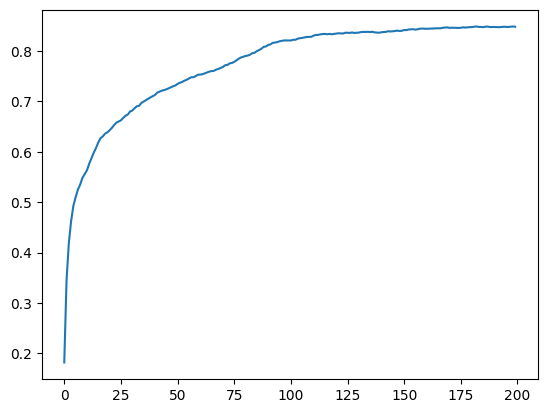

In [39]:
plt.plot(accuracies)

In [40]:
# test_data = DataLoader(test_dataset, batch_size=128)

model.eval()
total = 0
total2 = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x)
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1,10,10)
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = torch.argmax(y,axis=1).reshape(-1)
        z = (y == pred)
        total2+=z.sum()
        z = z.reshape(-1,10)
        total += torch.where(torch.abs(torch.sum(z,dim = 1)- 10)<=0, 1,0).sum()

print(total2/test_size/10,total/test_size)

tensor(0.8356, device='cuda:0') tensor(0.2350, device='cuda:0')


In [41]:
with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device)
        pred = model(x.reshape(1,-1))
        pred = torch.sigmoid(pred)
        
        pred = pred.reshape(-1,10,10).cpu()
        pred = torch.argmax(pred,axis=1).reshape(-1)
        y = y.reshape(-1,10,10)
        y = np.argmax(y,axis=1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x)
        print("pred : ",pred)
        print("true : ",y)

5 testcase
x :  tensor([-0.7413,  1.6795,  0.6962, -0.6798, -1.0554,  1.3927, -1.1715,  0.2045,
        -0.4476,  0.1226], device='cuda:0')
pred :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1])
true :  tensor([6, 4, 0, 3, 8, 9, 7, 2, 5, 1])
10 testcase
x :  tensor([-0.1977, -1.0546,  0.0791,  0.5932, -0.1780, -0.2768,  1.7532, -0.5998,
         1.3446, -1.4632], device='cuda:0')
pred :  tensor([9, 1, 7, 7, 5, 2, 3, 3, 8, 6])
true :  tensor([9, 1, 7, 5, 0, 4, 2, 3, 8, 6])
15 testcase
x :  tensor([-0.7236, -0.1601, -0.9237, -0.4173,  2.2777, -0.6174,  0.3912, -0.0253,
        -0.8175,  1.0160], device='cuda:0')
pred :  tensor([2, 8, 0, 5, 3, 1, 1, 6, 9, 4])
true :  tensor([2, 8, 0, 5, 3, 1, 7, 6, 9, 4])
20 testcase
x :  tensor([ 0.9473, -0.1162,  1.7517, -1.1934, -1.1320,  0.6712,  0.4155, -0.1674,
        -1.2854,  0.1087], device='cuda:0')
pred :  tensor([8, 3, 4, 7, 7, 9, 6, 5, 0, 2])
true :  tensor([8, 3, 4, 7, 1, 9, 6, 5, 0, 2])
25 testcase
x :  tensor([-0.6228,  0.5959, -0.8100,  0.5236, 

In [42]:
import seaborn as sns

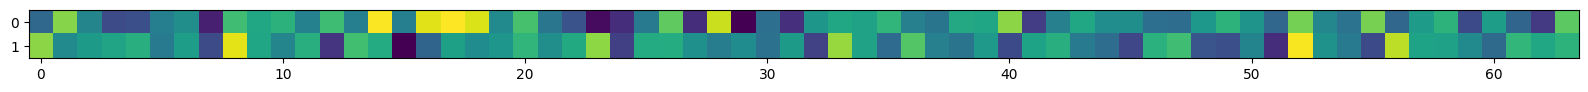

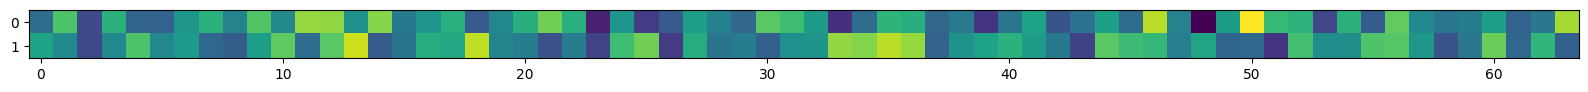

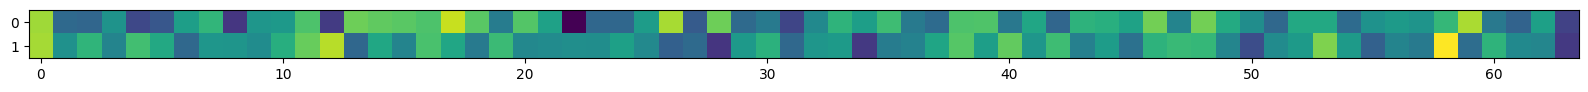

In [43]:


model.eval()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()

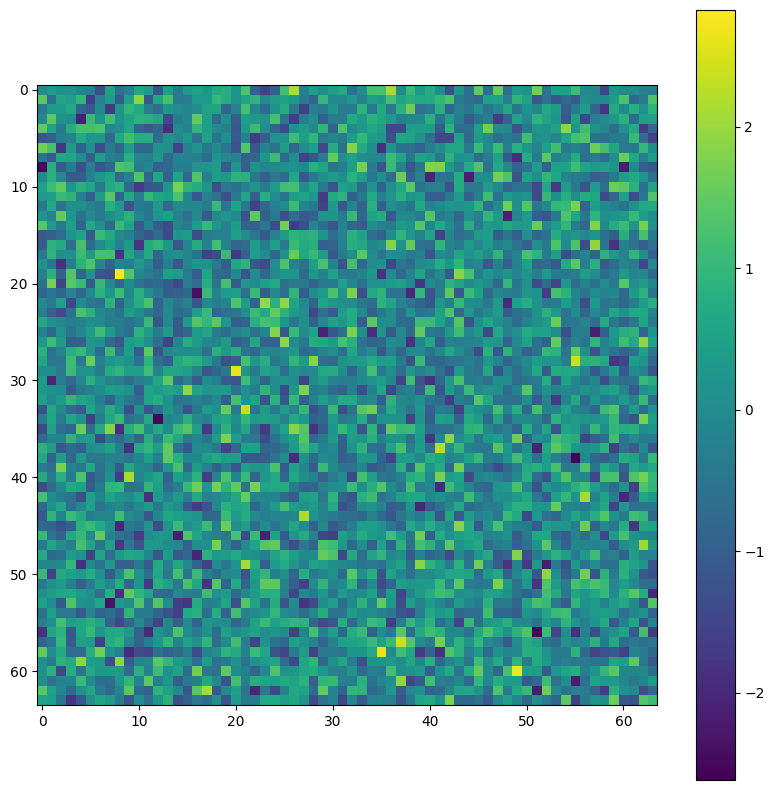

In [44]:
plt.figure(figsize=(10, 10))
plt.imshow(model.att.W_O.cpu().detach().numpy())
plt.colorbar()

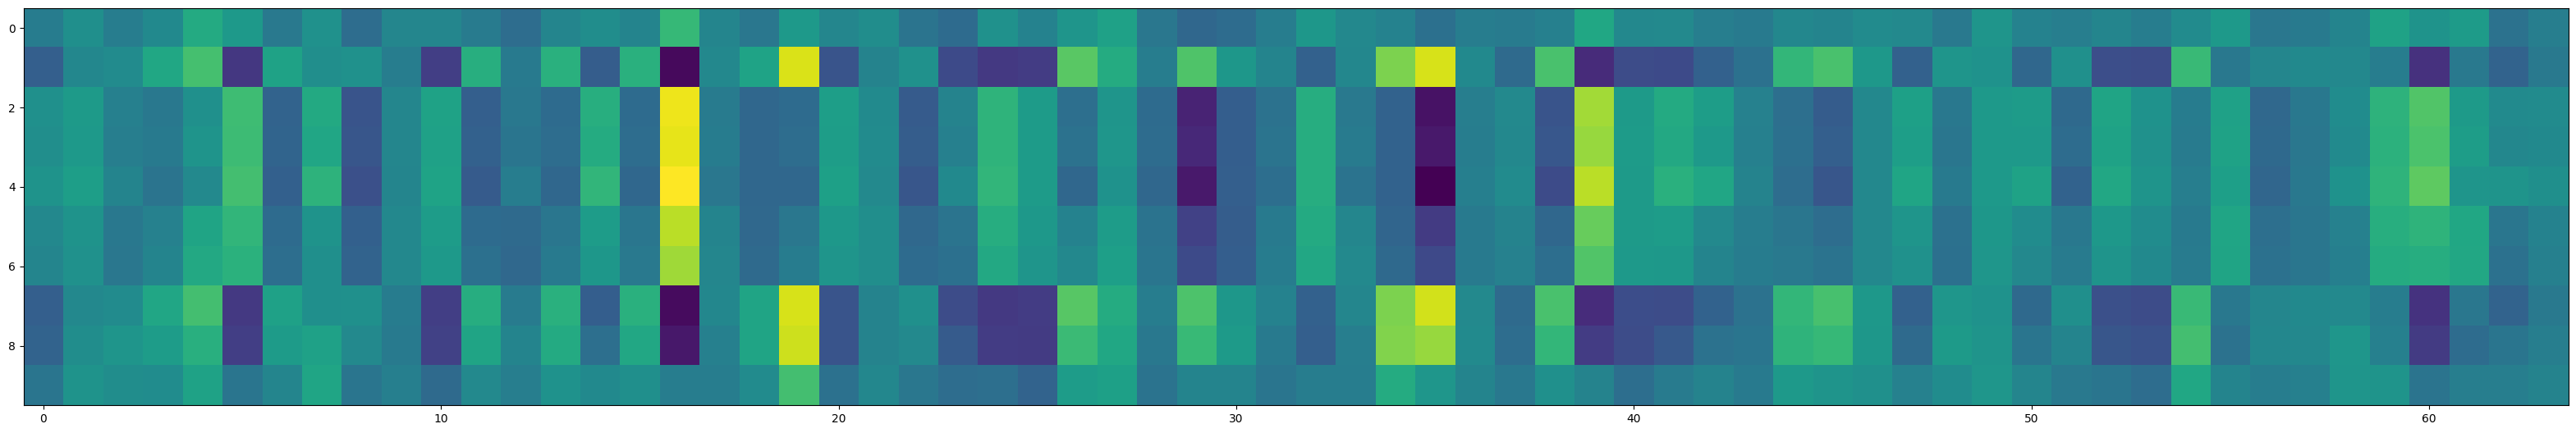

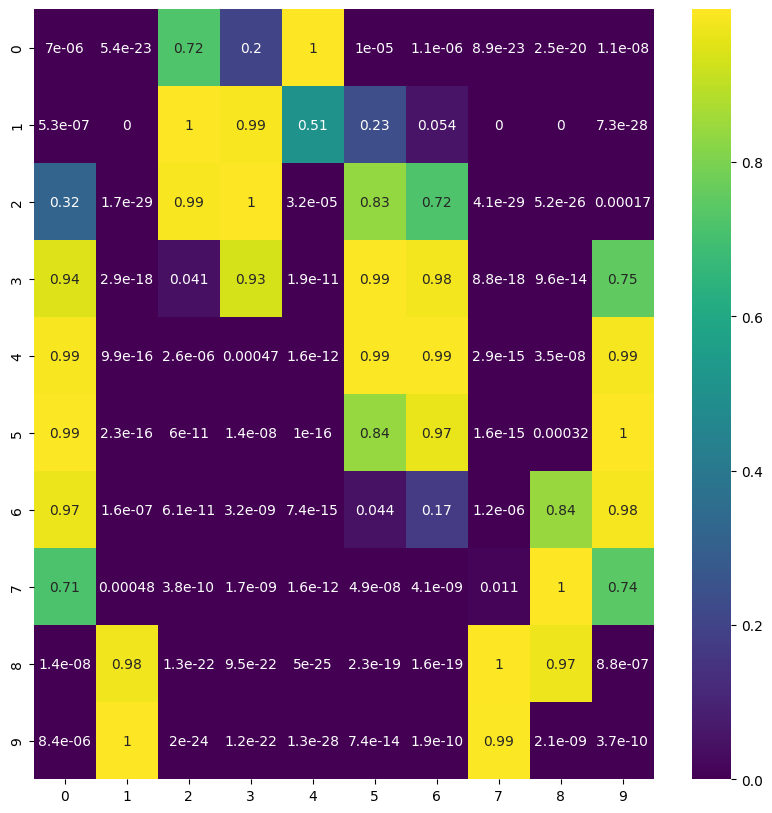

tensor([5, 9, 1, 2, 0, 3, 4, 8, 7, 6])
tensor([[5, 9, 1, 2, 0, 4, 4, 8, 7, 5]])


In [45]:
x,y = test_dataset[0]
x = x.reshape(1,-1).to(device)
x2 = model.position_embedded(x)
x3 = model.att(x2)
plt.figure(figsize=(40, 20))
plt.imshow(x3.cpu().detach().numpy()[0])
plt.show()
#print(x3.shape)
x4 = model.norm(x2,x3)
x5 = model.ff(x4)
plt.figure(figsize=(10, 10))
sns.heatmap(torch.sigmoid(x5.mT).cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()
print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))

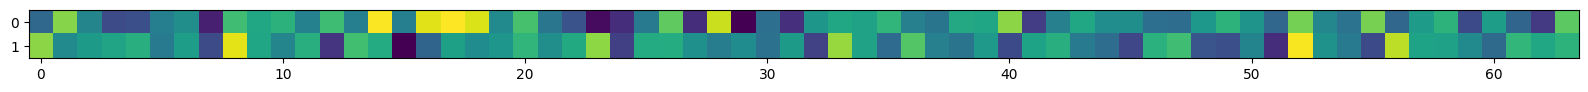

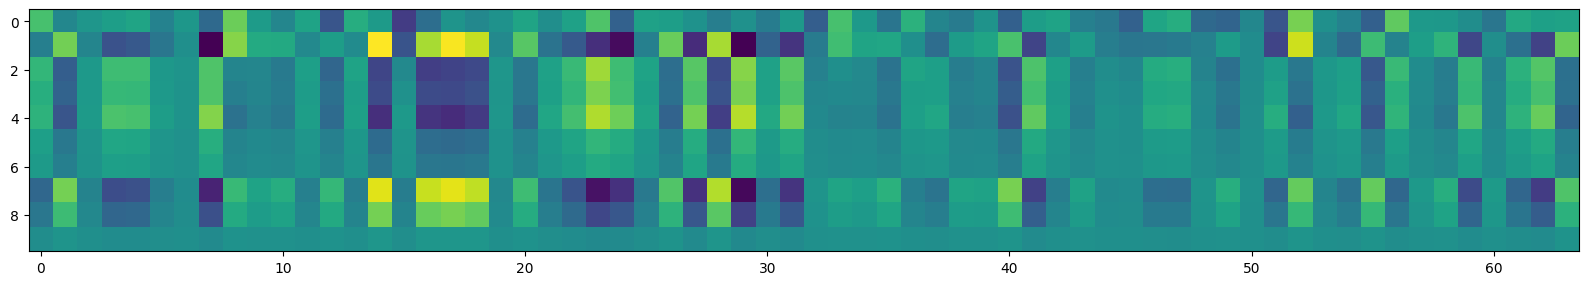

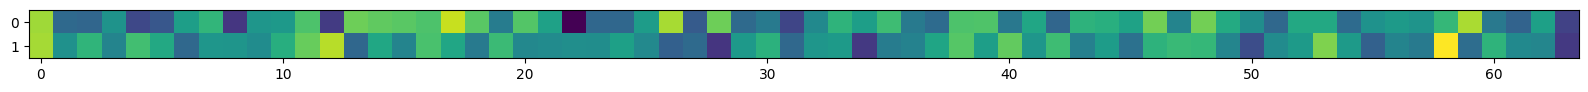

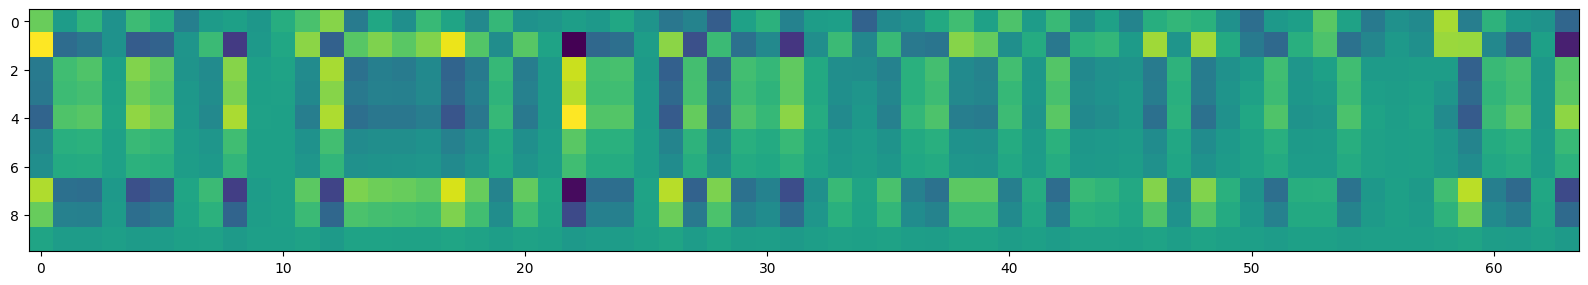

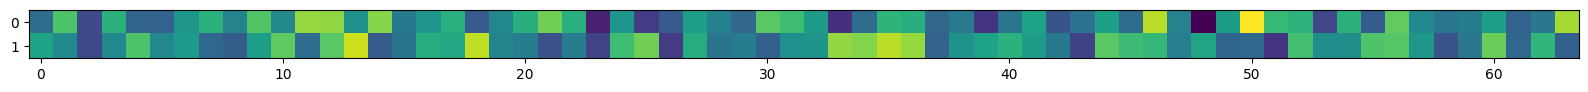

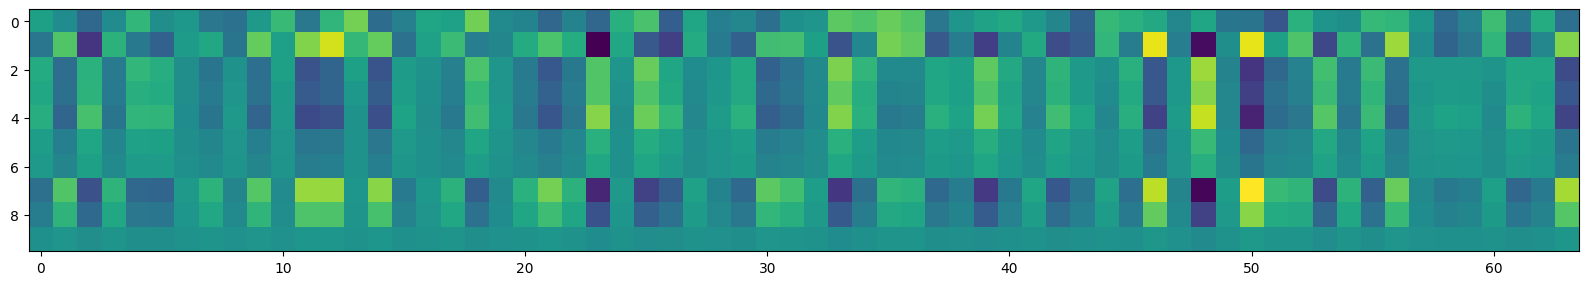

In [46]:
Q = x2@model.att.W_Q
K = x2@model.att.W_K
V = x2@model.att.W_V
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(Q.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(K.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(V.cpu().detach().numpy()[0])
plt.show()

torch.Size([1, 10, 16])


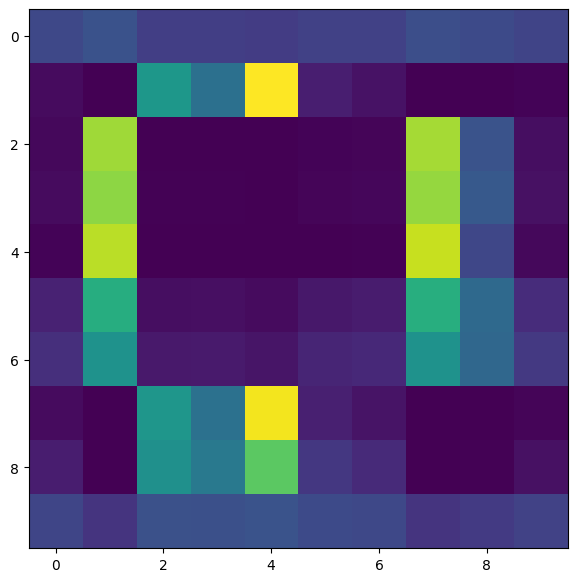

tensor([5, 9, 1, 2, 0, 3, 4, 8, 7, 6])
tensor([[5, 9, 1, 2, 0, 4, 4, 8, 7, 5]])


In [47]:
# Attention score of a head

Q = (x2@model.att.W_Q)[:,:,:model.att.attention_layers]
K = (x2@model.att.W_K)[:,:,:model.att.attention_layers]
V = (x2@model.att.W_V)[:,:,:model.att.attention_layers]

att_sc = model.att.sf(Q@(K.mT))
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(att_sc.cpu().detach().numpy()[0])
plt.show()

print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))

In [48]:
# # Saving the model for future references 
# import time
# torch.save(model.state_dict(), f"model{time.time()}.trhmodel")

torch.Size([1, 10, 16])


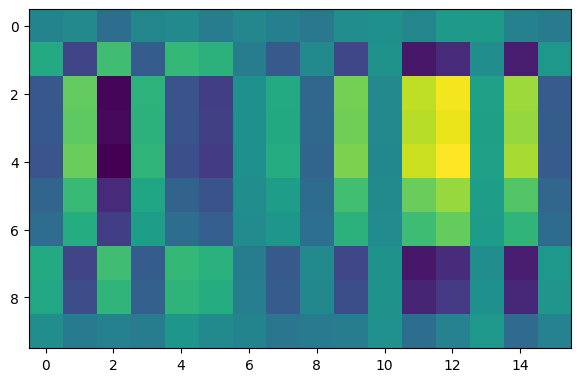

tensor([5, 9, 1, 2, 0, 3, 4, 8, 7, 6])
tensor([[5, 9, 1, 2, 0, 4, 4, 8, 7, 5]])


In [49]:
# after applying Attention score 
W = att_sc@V
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(W.cpu().detach().numpy()[0])
plt.show()

print(np.argmax(y.reshape((10,10)),axis=1))
print(torch.argmax(torch.sigmoid(x5.mT).cpu(),dim=1))